# Clustering Analysis using KMeans

## Setup

In [1]:

import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA


In [2]:

import sys

PROJECT_ROOT = Path().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import load_config

config = load_config()
PROCESSED_DATA_PATH = PROJECT_ROOT / config["data"]["processed_path"]
PROCESSED_DATA_PATH


PosixPath('/Users/janmeet/Desktop/Projects/bank-marketing copy/data/processed/bank_marketing_preprocessed.csv')

## Load Data

In [3]:

from src.data import load_processed

df = load_processed(config["data"]["processed_path"])
target_col = "y"
if target_col in df.columns:
    y = df[target_col]
    X_df = df.drop(columns=[target_col])
else:
    y = None
    X_df = df.copy()


## KMeans

In [4]:

from src.clustering import find_best_k

cluster_cfg = config["clustering"]
best_k, scores_by_k = find_best_k(
    X_df, cluster_cfg["k_min"], cluster_cfg["k_max"], cluster_cfg["random_state"]
)
ks = list(scores_by_k.keys())
score = list(scores_by_k.values())
print("Best k =", best_k)


Best k = 2


In [5]:

from src.clustering import run_kmeans

kmeans, labels = run_kmeans(X_df, best_k, cluster_cfg["random_state"])
print(labels)


[0 0 0 ... 1 1 1]


/var/folders/qk/rc248dmj1zj7y1zrdw80z81h0000gn/T/ipykernel_99695/1450127196.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


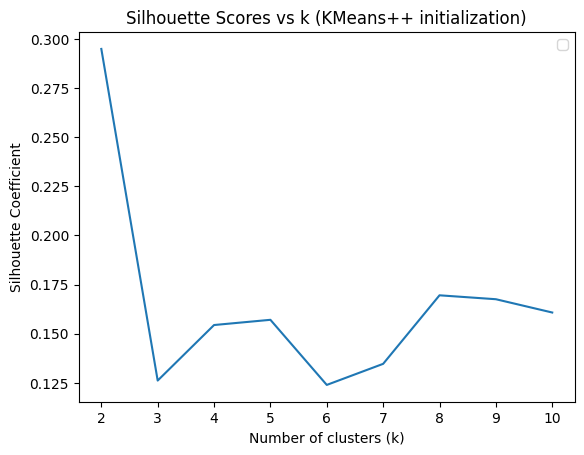

In [6]:
plt.figure()
plt.plot(ks, score)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Coefficient')
plt.legend()
plt.title('Silhouette Scores vs k (KMeans++ initialization)')
plt.savefig('silhouette_plot_kmeans++_init.png')
plt.show()

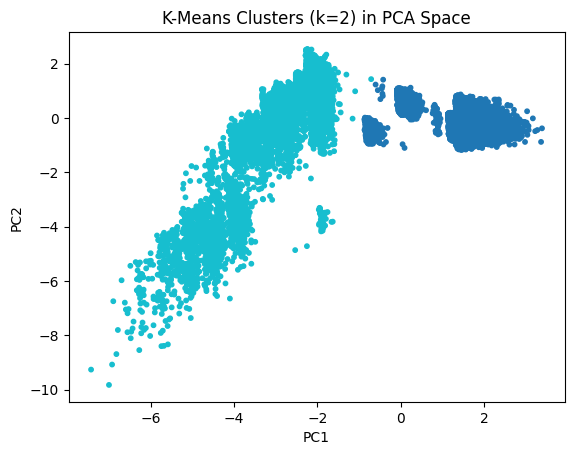

In [7]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_df)
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=10)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f"K-Means Clusters (k={best_k}) in PCA Space")
plt.show()

## Analyze Clustering

K-means assumes that the clusters are roughly spherical. PCA projection of the features in our dataset shows that the data forms elongated shapes but not perfect spheres. The data does not completely fit the assumptions of K-Means so it does not form perfect clusters.
Highest silhouette score occurs at k=2 and then drops sharply. It indicates that cluster separation weakens beyond k=2, and does not produce meaningful separation.